In [1]:
# =====================================================================
# PHẦN 0 — CÀI ĐẶT & IMPORT
# =====================================================================
!pip install -q pycocoevalcap rouge_score
!pip install -q datasets transformers accelerate Pillow requests nltk evaluate torch torchvision

import os

# 🔧 FIX OOM: giảm phân mảnh bộ nhớ CUDA allocator — PHẢI set trước khi import torch
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc, json, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from datasets import load_dataset
from transformers import (
    BlipProcessor, BlipForConditionalGeneration, get_linear_schedule_with_warmup
)
from torch.optim import AdamW
import evaluate
from pycocoevalcap.cider.cider import Cider
import pandas as pd

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CUDA available: {torch.cuda.is_available()}")

# 🔧 FIX OOM: helper dọn bộ nhớ, gọi sau mỗi phase train / định kỳ khi eval
def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


SHARED_PROCESSOR = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
PAD_ID = SHARED_PROCESSOR.tokenizer.pad_token_id

# Hyperparams dùng chung (giống tuần 3)
NUM_EPOCHS   = 10
BATCH_SIZE   = 4   # 🔧 nếu vẫn OOM sau các fix bên dưới, thử giảm xuống 2
LR           = 1e-5
MAX_LEN      = 64
WARMUP_RATIO = 0.1
ALPHA_SEQ    = 0.4   # trọng số pseudo-label loss cho Seq-KD
ALPHA_WORD   = 0.7   # trọng số KD loss cho Word-KD
ALPHA_FEAT   = 0.5   # trọng số feature loss cho Feature-KD (FitNets)
TEMPERATURE  = 4.0   # nhiệt độ softmax cho Word-KD

USE_AMP = torch.cuda.is_available()  # 🔧 FIX OOM: bật mixed-precision khi có GPU


def make_labels(input_ids: torch.Tensor) -> torch.Tensor:
    """Mask pad + BOS thành -100 để loss không tính vào"""
    labels = input_ids.clone()
    labels[labels == PAD_ID] = -100
    labels[:, 0] = -100
    return labels

def enable_ckpt(model):
    """🔧 FIX OOM: bật gradient checkpointing để giảm bộ nhớ activation lúc train."""
    try:
        model.gradient_checkpointing_enable()
        model.config.use_cache = False
    except Exception as e:
        print(f"[Cảnh báo] Không bật được gradient checkpointing: {e}")


def disable_ckpt(model):
    """🔧 FIX OOM: tắt lại checkpointing sau khi train xong, để .generate() eval hoạt động bình thường."""
    try:
        model.gradient_checkpointing_disable()
        model.config.use_cache = True
    except Exception as e:
        print(f"[Cảnh báo] Không tắt được gradient checkpointing: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 16.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00
CUDA available: True


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [2]:
# =====================================================================
# PHẦN 1 — TEACHER (BLIP-large, đóng băng)
# =====================================================================
teacher_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-large",
    torch_dtype=torch.float16
).to(DEVICE).eval()
for p in teacher_model.parameters():
    p.requires_grad = False


@torch.no_grad()
def get_pseudo_labels(pil_images):
    """Teacher sinh caption text, dùng cho Seq-KD"""
    inputs = SHARED_PROCESSOR(images=pil_images, return_tensors="pt", padding=True).to(DEVICE)
    inputs["pixel_values"] = inputs["pixel_values"].half()
    ids = teacher_model.generate(**inputs, max_new_tokens=40, num_beams=3, early_stopping=True)
    return SHARED_PROCESSOR.batch_decode(ids, skip_special_tokens=True)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
# =====================================================================
# PHẦN 2 — CHUẨN BỊ FASHION200K (1000 mẫu) + TÁCH TRAIN/VAL/TEST 70/15/15
# =====================================================================
N_SAMPLES  = 1000
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
# phần còn lại (0.15) là TEST

os.makedirs("data/fashion_images", exist_ok=True)
os.makedirs("data/subsets", exist_ok=True)

if os.path.exists("data/subsets/fashion_all.json"):
    print("fashion_all.json đã có sẵn, bỏ qua bước tải lại")
else:
    print(f"Đang tải {N_SAMPLES} mẫu từ Marqo/fashion200k (streaming)...")
    dataset = load_dataset("Marqo/fashion200k", split="data", streaming=True)
    samples = list(dataset.take(N_SAMPLES))

    metadata = []
    for idx, sample in enumerate(samples):
        caption = (sample.get("text") or "").strip()
        if not caption:
            continue  # bỏ mẫu thiếu caption, tránh lỗi khi train/eval

        img_path = f"data/fashion_images/img_{idx:04d}.jpg"
        img = sample["image"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img.save(img_path, quality=95)

        metadata.append({
            "id": idx,
            "item_id": sample.get("item_ID", idx),
            "image_path": img_path,
            "caption": caption,
            "category1": sample.get("category1", ""),
            "category2": sample.get("category2", ""),
            "category3": sample.get("category3", ""),
        })
    with open("data/subsets/fashion_all.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)
    print(f"Đã lưu {len(metadata)} mẫu hợp lệ")    

with open("data/subsets/fashion_all.json", encoding="utf-8") as f:
    fashion_all = json.load(f)

# Tách train/val/test, seed cố định để MỌI thí nghiệm trong tuần dùng
# chung 1 bộ val (so sánh phương pháp) và 1 bộ test (để dành, dùng 1 lần)
indices = list(range(len(fashion_all)))
random.Random(RANDOM_SEED).shuffle(indices)

n = len(indices)
train_end = int(n * TRAIN_FRAC)
val_end   = int(n * (TRAIN_FRAC + VAL_FRAC))

fashion_train = [fashion_all[i] for i in indices[:train_end]]
fashion_val   = [fashion_all[i] for i in indices[train_end:val_end]]
fashion_test  = [fashion_all[i] for i in indices[val_end:]]

with open("data/subsets/fashion_train.json", "w", encoding="utf-8") as f:
    json.dump(fashion_train, f, ensure_ascii=False, indent=2)
with open("data/subsets/fashion_val.json", "w", encoding="utf-8") as f:
    json.dump(fashion_val, f, ensure_ascii=False, indent=2)
with open("data/subsets/fashion_test.json", "w", encoding="utf-8") as f:
    json.dump(fashion_test, f, ensure_ascii=False, indent=2)

print(f"Train: {len(fashion_train)} | Val: {len(fashion_val)} | Test: {len(fashion_test)} "
      f"(seed={RANDOM_SEED})")
print("⚠️ fashion_test đã lưu ra nhưng KHÔNG dùng trong file này — để dành cho báo cáo cuối kỳ.")

steps_per_epoch = max(1, len(fashion_train) // BATCH_SIZE)
total_steps  = steps_per_epoch * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

Đang tải 1000 mẫu từ Marqo/fashion200k (streaming)...


README.md: 0.00B [00:00, ?B/s]

Đã lưu 1000 mẫu hợp lệ
Train: 700 | Val: 150 | Test: 150 (seed=42)
⚠️ fashion_test đã lưu ra nhưng KHÔNG dùng trong file này — để dành cho báo cáo cuối kỳ.


In [4]:
# =====================================================================
# PHẦN 3 — HÀM ĐÁNH GIÁ (nhận eval_metadata riêng, không đụng train)
# =====================================================================
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
cider_scorer = Cider()


def evaluate_model(model, eval_metadata, is_teacher=False, max_samples=None):
    model.eval()
    predictions, references = [], []
    cider_refs, cider_preds = {}, {}

    samples_to_eval = eval_metadata[:max_samples] if max_samples else eval_metadata
    print(f"Đang đánh giá trên {len(samples_to_eval)} mẫu...")

    with torch.no_grad():
        for i, item in enumerate(samples_to_eval):
            img = Image.open(item["image_path"]).convert("RGB")
            inputs = SHARED_PROCESSOR(images=img, return_tensors="pt").to(DEVICE)
            if is_teacher:
                inputs["pixel_values"] = inputs["pixel_values"].half()

            generated_ids = model.generate(**inputs, max_new_tokens=40)
            pred = SHARED_PROCESSOR.decode(generated_ids[0], skip_special_tokens=True)

            predictions.append(pred)
            references.append([item["caption"]])
            cider_preds[i] = [pred]
            cider_refs[i] = [item["caption"]]

            # 🔧 FIX OOM: dọn bộ nhớ định kỳ khi eval nhiều mẫu liên tiếp
            if (i + 1) % 25 == 0:
                free_memory()

    bleu_score  = bleu.compute(predictions=predictions, references=references)["bleu"]
    rouge_score = rouge.compute(predictions=predictions, references=references)["rougeL"]
    (cider_score, _) = cider_scorer.compute_score(cider_refs, cider_preds)
    return bleu_score, rouge_score, cider_score

In [5]:
# =====================================================================
# PHẦN 4 — SEQ-KD trên Fashion200k (train)
# =====================================================================
student_model_seqkd = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(DEVICE)
enable_ckpt(student_model_seqkd)  # 🔧 FIX OOM

optimizer_seq = AdamW(student_model_seqkd.parameters(), lr=LR, weight_decay=0.01)
scheduler_seq = get_linear_schedule_with_warmup(
    optimizer_seq, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
scaler_seq = torch.cuda.amp.GradScaler(enabled=USE_AMP)  # 🔧 FIX OOM

loss_log = []
print(f"Training: {NUM_EPOCHS} epochs | {total_steps} steps | warmup {warmup_steps} steps")


for epoch in range(NUM_EPOCHS):
    student_model_seqkd.train()
    epoch_losses = []

    for start in range(0, len(fashion_train), BATCH_SIZE):
        batch = fashion_train[start:start + BATCH_SIZE]
        if not batch:
            continue
        pil_imgs = [Image.open(b["image_path"]).convert("RGB") for b in batch]
        gt_caps  = [b["caption"] for b in batch]
        pseudo_caps = get_pseudo_labels(pil_imgs)

        gt_enc = SHARED_PROCESSOR(
            images=pil_imgs, text=gt_caps, return_tensors="pt",
            padding="max_length", max_length=MAX_LEN, truncation=True
        ).to(DEVICE)
        ps_enc = SHARED_PROCESSOR(
            images=pil_imgs, text=pseudo_caps, return_tensors="pt",
            padding="max_length", max_length=MAX_LEN, truncation=True
        ).to(DEVICE)

        # 🔧 FIX OOM: mixed-precision forward
        with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=torch.float16):
            out_gt = student_model_seqkd(
                pixel_values=gt_enc["pixel_values"], input_ids=gt_enc["input_ids"],
                attention_mask=gt_enc["attention_mask"], labels=make_labels(gt_enc["input_ids"])
            )
            out_pseudo = student_model_seqkd(
                pixel_values=ps_enc["pixel_values"], input_ids=ps_enc["input_ids"],
                attention_mask=ps_enc["attention_mask"], labels=make_labels(ps_enc["input_ids"])
            )
            loss = (1 - ALPHA_SEQ) * out_gt.loss + ALPHA_SEQ * out_pseudo.loss

        optimizer_seq.zero_grad()
        scaler_seq.scale(loss).backward()
        scaler_seq.unscale_(optimizer_seq)
        torch.nn.utils.clip_grad_norm_(student_model_seqkd.parameters(), 1.0)
        scaler_seq.step(optimizer_seq)
        scaler_seq.update()
        scheduler_seq.step()
        epoch_losses.append(loss.item())

    avg = sum(epoch_losses) / len(epoch_losses)
    loss_log.append(avg)
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | loss={avg:.4f} "
          f"| LR={scheduler_seq.get_last_lr()[0]:.2e}")

disable_ckpt(student_model_seqkd)  # 🔧 FIX OOM: để .generate() eval sau này hoạt động đúng
# 🔧 FIX OOM: đây là fix QUAN TRỌNG NHẤT — xoá optimizer/scheduler ngay khi train xong,
# nếu không chúng sẽ "kẹt" bộ nhớ GPU suốt các phase Word-KD/Feature-KD/No-KD phía sau.
del optimizer_seq, scheduler_seq, scaler_seq
free_memory()


pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

/tmp/ipykernel_58/381121357.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_seq = torch.cuda.amp.GradScaler(enabled=USE_AMP)  # 🔧 FIX OOM


Training: 10 epochs | 1750 steps | warmup 175 steps


/tmp/ipykernel_58/381121357.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=torch.float16):
/tmp/ipykernel_58/381121357.py:58: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler_seq.step()


Epoch  1/10 | loss=2.1715 | LR=1.00e-05
Epoch  2/10 | loss=1.1459 | LR=8.89e-06
Epoch  3/10 | loss=0.7355 | LR=7.78e-06
Epoch  4/10 | loss=0.5519 | LR=6.67e-06
Epoch  5/10 | loss=0.4496 | LR=5.56e-06
Epoch  6/10 | loss=0.3737 | LR=4.44e-06
Epoch  7/10 | loss=0.3098 | LR=3.33e-06
Epoch  8/10 | loss=0.2631 | LR=2.22e-06
Epoch  9/10 | loss=0.2257 | LR=1.11e-06
Epoch 10/10 | loss=0.2010 | LR=0.00e+00


In [6]:
# =====================================================================
# PHẦN 5 — WORD-KD trên Fashion200k (train)
# =====================================================================
student_model_wordkd = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(DEVICE)
enable_ckpt(student_model_wordkd)  # 🔧 FIX OOM

optimizer_word = AdamW(student_model_wordkd.parameters(), lr=LR, weight_decay=0.01)
scheduler_word = get_linear_schedule_with_warmup(
    optimizer_word, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
scaler_word = torch.cuda.amp.GradScaler(enabled=USE_AMP)  # 🔧 FIX OOM


def compute_word_kd_loss(student_logits, teacher_logits, pad_mask, T=TEMPERATURE):
    student_log_probs = F.log_softmax(student_logits / T, dim=-1)
    teacher_probs = F.softmax(teacher_logits.float() / T, dim=-1)
    kd_per_token = F.kl_div(student_log_probs, teacher_probs, reduction="none").sum(dim=-1)
    kd_per_token = kd_per_token * pad_mask
    return (kd_per_token.sum() / pad_mask.sum().clamp(min=1)) * (T ** 2)


print("Training Word-KD trên Fashion200k...")
for epoch in range(NUM_EPOCHS):
    student_model_wordkd.train()
    epoch_losses = []

    for start in range(0, len(fashion_train), BATCH_SIZE):
        batch = fashion_train[start:start + BATCH_SIZE]
        if not batch:
            continue
        pil_imgs = [Image.open(b["image_path"]).convert("RGB") for b in batch]
        gt_caps  = [b["caption"] for b in batch]

        gt_enc = SHARED_PROCESSOR(
            images=pil_imgs, text=gt_caps, return_tensors="pt",
            padding="max_length", max_length=MAX_LEN, truncation=True
        ).to(DEVICE)
        gt_labels = make_labels(gt_enc["input_ids"])
        pad_mask = (gt_labels != -100).float()

        with torch.no_grad():
            teacher_out = teacher_model(
                pixel_values=gt_enc["pixel_values"].half(),
                input_ids=gt_enc["input_ids"], attention_mask=gt_enc["attention_mask"]
            )
            teacher_logits = teacher_out.logits

        # 🔧 FIX OOM: mixed-precision forward (giữ NGUYÊN việc KHÔNG clip_grad_norm_,
        # đúng như bản gốc, để so sánh công bằng với kết quả tuần trước)
        with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=torch.float16):
            student_out = student_model_wordkd(
                pixel_values=gt_enc["pixel_values"], input_ids=gt_enc["input_ids"],
                attention_mask=gt_enc["attention_mask"], labels=gt_labels
            )
            loss_gt = student_out.loss
            loss_kd = compute_word_kd_loss(student_out.logits, teacher_logits, pad_mask)
            loss = (1 - ALPHA_WORD) * loss_gt + ALPHA_WORD * loss_kd

        optimizer_word.zero_grad()
        scaler_word.scale(loss).backward()
        scaler_word.step(optimizer_word)
        scaler_word.update()
        scheduler_word.step()
        epoch_losses.append(loss.item())

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {sum(epoch_losses)/len(epoch_losses):.4f}")

disable_ckpt(student_model_wordkd)  # 🔧 FIX OOM
# 🔧 FIX OOM: giải phóng optimizer/scheduler của Word-KD trước khi sang Feature-KD
del optimizer_word, scheduler_word, scaler_word
free_memory()

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Training Word-KD trên Fashion200k...


/tmp/ipykernel_58/1482745445.py:65: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler_word.step()


Epoch 1/10 | Loss: 1.1778
Epoch 2/10 | Loss: 0.7485
Epoch 3/10 | Loss: 0.5995
Epoch 4/10 | Loss: 0.4548
Epoch 5/10 | Loss: 0.3839
Epoch 6/10 | Loss: 0.3491
Epoch 7/10 | Loss: 0.3252
Epoch 8/10 | Loss: 0.3072
Epoch 9/10 | Loss: 0.2937
Epoch 10/10 | Loss: 0.2853


In [7]:
8# =====================================================================
# PHẦN 6 — FEATURE-KD trên Fashion200k (FitNets gốc, chưa dùng biến thể)
# =====================================================================
# Teacher (BLIP-large, vision hidden=1024) dạy Student (BLIP-base, hidden=768)
# qua feature ảnh đã pooled (không so từng patch, tránh lệch số token nếu
# 2 model xử lý resolution khác nhau) -> cần Adapter (Linear) để khớp chiều.
# Đây đúng công thức gốc của FitNets (Romero et al. 2015): Hint loss = MSE
# giữa feature Student (qua Adapter) và feature Teacher.

student_model_featurekd = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(DEVICE)
enable_ckpt(student_model_featurekd)  # 🔧 FIX OOM

teacher_hidden = teacher_model.vision_model.config.hidden_size   # BLIP-large: 1024
student_hidden = student_model_featurekd.vision_model.config.hidden_size  # BLIP-base: 768
print(f"Teacher vision hidden dim: {teacher_hidden} | Student vision hidden dim: {student_hidden}")

adapter = nn.Linear(student_hidden, teacher_hidden).to(DEVICE)

optimizer_feat = AdamW(
    list(student_model_featurekd.parameters()) + list(adapter.parameters()),
    lr=LR, weight_decay=0.01
)
scheduler_feat = get_linear_schedule_with_warmup(
    optimizer_feat, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
scaler_feat = torch.cuda.amp.GradScaler(enabled=USE_AMP)  # 🔧 FIX OOM


def get_pooled_image_feature(model, pixel_values):
    """Lấy pooled feature (CLS-pooled) từ vision encoder của BLIP."""
    vision_out = model.vision_model(pixel_values=pixel_values)
    return vision_out.pooler_output


print("Training Feature-KD (FitNets) trên Fashion200k...")
for epoch in range(NUM_EPOCHS):
    student_model_featurekd.train()
    adapter.train()
    epoch_losses = []

    for start in range(0, len(fashion_train), BATCH_SIZE):
        batch = fashion_train[start:start + BATCH_SIZE]
        if not batch:
            continue
        pil_imgs = [Image.open(b["image_path"]).convert("RGB") for b in batch]
        gt_caps  = [b["caption"] for b in batch]

        gt_enc = SHARED_PROCESSOR(
            images=pil_imgs, text=gt_caps, return_tensors="pt",
            padding="max_length", max_length=MAX_LEN, truncation=True
        ).to(DEVICE)
        gt_labels = make_labels(gt_enc["input_ids"])

        with torch.no_grad():
            teacher_feat = get_pooled_image_feature(
                teacher_model, gt_enc["pixel_values"].half()
            ).float()

        # 🔧 FIX OOM: mixed-precision forward
        with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=torch.float16):
            student_feat = get_pooled_image_feature(student_model_featurekd, gt_enc["pixel_values"])
            adapted_feat = adapter(student_feat)
            loss_feature = F.mse_loss(adapted_feat.float(), teacher_feat)

            out_gt = student_model_featurekd(
                pixel_values=gt_enc["pixel_values"], input_ids=gt_enc["input_ids"],
                attention_mask=gt_enc["attention_mask"], labels=gt_labels
            )
            loss = (1 - ALPHA_FEAT) * out_gt.loss + ALPHA_FEAT * loss_feature

        optimizer_feat.zero_grad()
        scaler_feat.scale(loss).backward()
        scaler_feat.unscale_(optimizer_feat)
        torch.nn.utils.clip_grad_norm_(
            list(student_model_featurekd.parameters()) + list(adapter.parameters()), 1.0
        )
        scaler_feat.step(optimizer_feat)
        scaler_feat.update()
        scheduler_feat.step()
        epoch_losses.append(loss.item())

    avg = sum(epoch_losses) / len(epoch_losses)
    print(f"[Feature-KD] Epoch {epoch+1:2d}/{NUM_EPOCHS} | loss={avg:.4f} "
          f"(gt={out_gt.loss.item():.4f}, feat={loss_feature.item():.4f})")

disable_ckpt(student_model_featurekd)  # 🔧 FIX OOM
# 🔧 FIX OOM: adapter chỉ cần lúc train (không dùng khi generate caption ở Phần 8)
# nên xoá luôn cùng optimizer/scheduler để giải phóng bộ nhớ trước phase No-KD.
del optimizer_feat, scheduler_feat, scaler_feat, adapter
free_memory()

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Teacher vision hidden dim: 1024 | Student vision hidden dim: 768
Training Feature-KD (FitNets) trên Fashion200k...


/tmp/ipykernel_58/3656429630.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_feat = torch.cuda.amp.GradScaler(enabled=USE_AMP)  # 🔧 FIX OOM
/tmp/ipykernel_58/3656429630.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=torch.float16):
/tmp/ipykernel_58/3656429630.py:81: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler_feat.step()


[Feature-KD] Epoch  1/10 | loss=1.7844 (gt=2.0956, feat=0.3652)
[Feature-KD] Epoch  2/10 | loss=0.8542 (gt=1.2910, feat=0.2534)
[Feature-KD] Epoch  3/10 | loss=0.5498 (gt=0.9422, feat=0.2434)
[Feature-KD] Epoch  4/10 | loss=0.4328 (gt=0.7574, feat=0.2406)
[Feature-KD] Epoch  5/10 | loss=0.3644 (gt=0.6083, feat=0.2372)
[Feature-KD] Epoch  6/10 | loss=0.3129 (gt=0.5243, feat=0.2348)
[Feature-KD] Epoch  7/10 | loss=0.2731 (gt=0.4783, feat=0.2318)
[Feature-KD] Epoch  8/10 | loss=0.2419 (gt=0.3772, feat=0.2290)
[Feature-KD] Epoch  9/10 | loss=0.2192 (gt=0.3570, feat=0.2268)
[Feature-KD] Epoch 10/10 | loss=0.2042 (gt=0.2982, feat=0.2259)


In [8]:
# =====================================================================
# PHẦN 7 — BASELINE KHÔNG DÙNG KD (chỉ fine-tune trên nhãn gốc)
# =====================================================================
# Mục đích: chứng minh KD thực sự tạo ra giá trị — nếu Seq-KD/Word-KD/
# Feature-KD không vượt được baseline này ở cùng kích thước/tốc độ, thì
# lý do "cần KD" chưa đủ thuyết phục trước hội đồng.

student_model_nokd = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(DEVICE)
enable_ckpt(student_model_nokd)  # 🔧 FIX OOM

optimizer_nokd = AdamW(student_model_nokd.parameters(), lr=LR, weight_decay=0.01)
scheduler_nokd = get_linear_schedule_with_warmup(
    optimizer_nokd, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
scaler_nokd = torch.cuda.amp.GradScaler(enabled=USE_AMP)  # 🔧 FIX OOM

print("Training baseline KHÔNG dùng KD (chỉ fine-tune trên nhãn gốc)...")
for epoch in range(NUM_EPOCHS):
    student_model_nokd.train()
    epoch_losses = []

    for start in range(0, len(fashion_train), BATCH_SIZE):
        batch = fashion_train[start:start + BATCH_SIZE]
        if not batch:
            continue
        pil_imgs = [Image.open(b["image_path"]).convert("RGB") for b in batch]
        gt_caps  = [b["caption"] for b in batch]

        gt_enc = SHARED_PROCESSOR(
            images=pil_imgs, text=gt_caps, return_tensors="pt",
            padding="max_length", max_length=MAX_LEN, truncation=True
        ).to(DEVICE)
        gt_labels = make_labels(gt_enc["input_ids"])

        # 🔧 FIX OOM: mixed-precision forward
        with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=torch.float16):
            out = student_model_nokd(
                pixel_values=gt_enc["pixel_values"], input_ids=gt_enc["input_ids"],
                attention_mask=gt_enc["attention_mask"], labels=gt_labels
            )
            loss = out.loss  # KHÔNG có teacher, KHÔNG có KD loss nào

        optimizer_nokd.zero_grad()
        scaler_nokd.scale(loss).backward()
        scaler_nokd.unscale_(optimizer_nokd)
        torch.nn.utils.clip_grad_norm_(student_model_nokd.parameters(), 1.0)
        scaler_nokd.step(optimizer_nokd)
        scaler_nokd.update()
        scheduler_nokd.step()
        epoch_losses.append(loss.item())

    avg = sum(epoch_losses) / len(epoch_losses)
    print(f"[No-KD baseline] Epoch {epoch+1:2d}/{NUM_EPOCHS} | loss={avg:.4f}")

disable_ckpt(student_model_nokd)  # 🔧 FIX OOM
del optimizer_nokd, scheduler_nokd, scaler_nokd
free_memory()


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Training baseline KHÔNG dùng KD (chỉ fine-tune trên nhãn gốc)...


/tmp/ipykernel_58/3245836955.py:51: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler_nokd.step()


[No-KD baseline] Epoch  1/10 | loss=2.9552
[No-KD baseline] Epoch  2/10 | loss=1.3870
[No-KD baseline] Epoch  3/10 | loss=0.8187
[No-KD baseline] Epoch  4/10 | loss=0.5897
[No-KD baseline] Epoch  5/10 | loss=0.4576
[No-KD baseline] Epoch  6/10 | loss=0.3563
[No-KD baseline] Epoch  7/10 | loss=0.2821
[No-KD baseline] Epoch  8/10 | loss=0.2255
[No-KD baseline] Epoch  9/10 | loss=0.1813
[No-KD baseline] Epoch 10/10 | loss=0.1541


--- Đánh giá Teacher (Large) ---
Đang đánh giá trên 150 mẫu...
--- Đánh giá baseline KHÔNG dùng KD ---
Đang đánh giá trên 150 mẫu...
--- Đánh giá Seq-KD ---
Đang đánh giá trên 150 mẫu...
--- Đánh giá Word-KD ---
Đang đánh giá trên 150 mẫu...
--- Đánh giá Feature-KD ---
Đang đánh giá trên 150 mẫu...

BẢNG KẾT QUẢ TUẦN 4 (đánh giá trên VAL SET, Fashion200k 1000 mẫu, split 70/15/15)


,Metric,Teacher (Large),No-KD (baseline),Seq-KD (Student),Word-KD (Student),Feature-KD (Student)
0,BLEU,0.0124,0.3407,0.0777,0.3505,0.3410
1,ROUGE-L,0.2177,0.5209,0.2873,0.5395,0.5191
2,CIDEr,0.0403,1.1413,0.2011,1.1130,1.0870


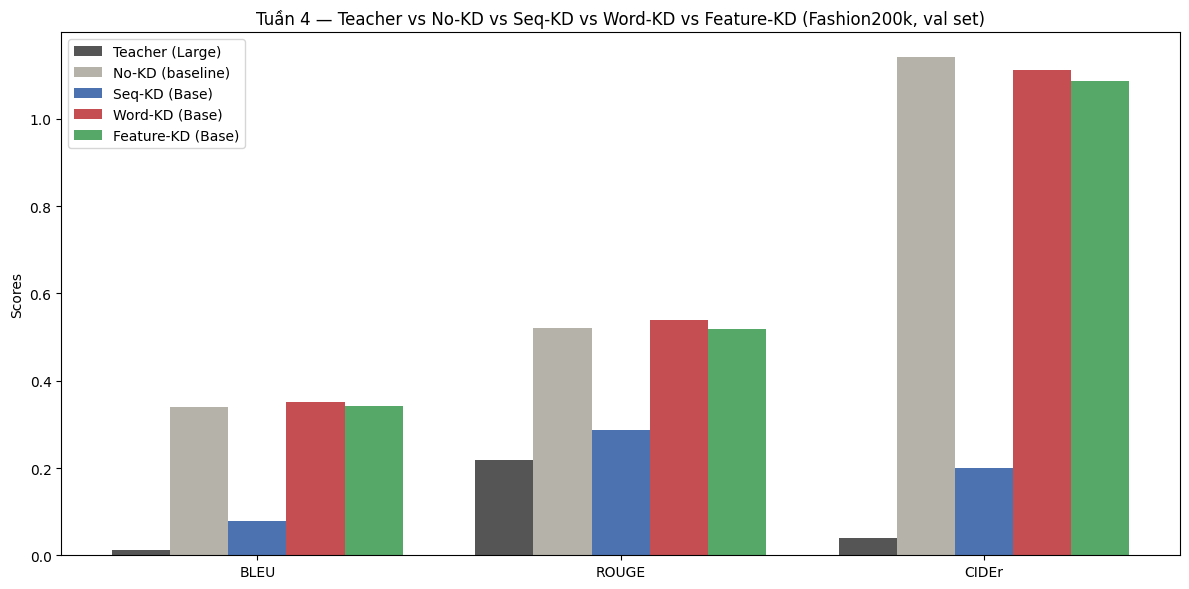

In [9]:
# =====================================================================
# PHẦN 8 — ĐÁNH GIÁ TRÊN VAL SET + BẢNG SO SÁNH 5 CỘT
# =====================================================================
# ⚠️ Dùng fashion_val — KHÔNG dùng fashion_test ở đây.

print("--- Đánh giá Teacher (Large) ---")
teach_bleu, teach_rouge, teach_cider = evaluate_model(teacher_model, fashion_val, is_teacher=True)
free_memory()  # 🔧 FIX OOM

print("--- Đánh giá baseline KHÔNG dùng KD ---")
nokd_bleu, nokd_rouge, nokd_cider = evaluate_model(student_model_nokd, fashion_val)
free_memory()  # 🔧 FIX OOM

print("--- Đánh giá Seq-KD ---")
seq_bleu, seq_rouge, seq_cider = evaluate_model(student_model_seqkd, fashion_val)
free_memory()  # 🔧 FIX OOM

print("--- Đánh giá Word-KD ---")
word_bleu, word_rouge, word_cider = evaluate_model(student_model_wordkd, fashion_val)
free_memory()  # 🔧 FIX OOM

print("--- Đánh giá Feature-KD ---")
feat_bleu, feat_rouge, feat_cider = evaluate_model(student_model_featurekd, fashion_val)
free_memory()  # 🔧 FIX OOM

data = {
    "Metric": ["BLEU", "ROUGE-L", "CIDEr"],
    "Teacher (Large)":       [teach_bleu, teach_rouge, teach_cider],
    "No-KD (baseline)":      [nokd_bleu, nokd_rouge, nokd_cider],
    "Seq-KD (Student)":      [seq_bleu, seq_rouge, seq_cider],
    "Word-KD (Student)":     [word_bleu, word_rouge, word_cider],
    "Feature-KD (Student)":  [feat_bleu, feat_rouge, feat_cider],
}
df_results = pd.DataFrame(data).round(4)
print("\nBẢNG KẾT QUẢ TUẦN 4 (đánh giá trên VAL SET, Fashion200k 1000 mẫu, split 70/15/15)")
display(df_results)

import matplotlib.pyplot as plt
import numpy as np

metrics = ['BLEU', 'ROUGE', 'CIDEr']
teacher_scores = [teach_bleu, teach_rouge, teach_cider]
nokd_scores    = [nokd_bleu, nokd_rouge, nokd_cider]
seq_scores     = [seq_bleu, seq_rouge, seq_cider]
word_scores    = [word_bleu, word_rouge, word_cider]
feat_scores    = [feat_bleu, feat_rouge, feat_cider]

x = np.arange(len(metrics))
width = 0.16

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 2*width, teacher_scores, width, label='Teacher (Large)', color='#555555')
ax.bar(x - 1*width, nokd_scores, width, label='No-KD (baseline)', color='#B4B2A9')
ax.bar(x + 0*width, seq_scores, width, label='Seq-KD (Base)', color='#4C72B0')
ax.bar(x + 1*width, word_scores, width, label='Word-KD (Base)', color='#C44E52')
ax.bar(x + 2*width, feat_scores, width, label='Feature-KD (Base)', color='#55A868')

ax.set_ylabel('Scores')
ax.set_title('Tuần 4 — Teacher vs No-KD vs Seq-KD vs Word-KD vs Feature-KD (Fashion200k, val set)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
fig.tight_layout()
plt.show()